In [113]:
from infrastructure.repository.csv_repository import TestRepository
from infrastructure.database.csv_session import get_session
from core.speed_test_service import NetworkSpeedService
from infrastructure.adapters.libre_speed_adapter import LibreSpeedAdapter, SpeedTestGoAdapter
from scipy import stats
from dataclasses import dataclass
from typing import Any, Callable
from matplotlib.axes import Axes
from scipy.stats import skew, bootstrap, wilcoxon
import matplotlib.pyplot as plt
import numpy as np
import numpy.typing as npt
  
def _prepare_data(data: list) -> npt.NDArray[Any]:
    
    s_lim = ((len(data))//10)*10

    return np.array(data[1:s_lim+1])
  
@dataclass(frozen=True)
class DataFrame:
    data: npt.NDArray[Any]
    label: str
    
    def get_statistical_summary(self) -> None:
        print(f"======= Statistical Summary {self.label} ======\n")
        print(f"N descarga:               {len(self.data)}")
        print(f"Media:                    {np.mean(self.data):.2f} Mbps")
        print(f"Desv. estándar:           {np.std(self.data, ddof=1):.2f} Mbps")
        print(f"Mínimo:                   {np.min(self.data):.2f} Mbps")
        print(f"Máximo:                   {np.max(self.data):.2f} Mbps")
        print(f"Coeficiente de asimetría: {abs(skew(self.data)):.4f}")
        print(f"==========================================================\n")
        
class PlotManager:
    
    @staticmethod
    def _make_histogram(frame: DataFrame, ax: Axes) -> None:

        data = frame.data

        ax.hist(
            data,
            bins=10,
            density=True,
            color='steelblue',
            alpha=0.7,
            edgecolor='white',
            label='Observed data'
        )

        x = np.linspace(data.min(), data.max(), 200)
        mu = np.mean(data)
        sigma = np.std(data, ddof=1)
        ax.plot(x, stats.norm.pdf(x, mu, sigma),
                color='crimson', linewidth=2,
                label=f'Theoretical normal (μ={mu:.2f}, σ={sigma:.2f})')

        ax.set_xlabel(f'{frame.label}')
        ax.set_ylabel('Density')
        ax.set_title('Data Distribution')
        ax.legend(fontsize=7)
        
    @staticmethod
    def _make_qq(frame: DataFrame, ax: Axes) -> None:

        (osm, osr), (slope, intercept, r) = stats.probplot(frame.data, dist="norm")

        ax.plot(osm, osr, 'o', color='steelblue', alpha=0.7,
                markersize=4, label='Observed data')

        ax.plot(
            osm,
            slope * np.array(osm) + intercept, # type: ignore
            color='crimson',
            linewidth=2,
            label='Normal reference line'
        )

        ax.set_xlabel('Theoretical quantiles')
        ax.set_ylabel('Observed quantiles')
        ax.set_title('Q-Q Plot')
        ax.legend(fontsize=7)
       
    @staticmethod 
    def _make_boxplot(frame: DataFrame, ax: Axes) -> None:

        ax.boxplot(
            frame.data,
            patch_artist=True,
            boxprops=dict(facecolor='steelblue', alpha=0.7),
            medianprops=dict(color='crimson', linewidth=2),
            flierprops=dict(marker='o', markerfacecolor='orange', markersize=5)
        )

        mean_val = float(np.mean(frame.data))
        ax.axhline(
            y=mean_val,
            color='green',
            linewidth=1.5,
            linestyle='--',
            label=f'Mean = {mean_val:.2f}'
        )

        ax.set_ylabel(f'{frame.label}')
        ax.set_title('Boxplot')
        ax.legend(fontsize=7)
        
    @classmethod
    def plot_normality_analysis(cls, frame: DataFrame) -> None:
        
        fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4))

        fig.suptitle(f'Normality Analysis — {frame.label}',
                    fontsize=13, fontweight='bold', y=1.02)

        cls._make_histogram(frame, ax1)
        cls._make_boxplot(frame, ax2)
        cls._make_qq(frame, ax3)

        plt.tight_layout()
        plt.show()
      
    @staticmethod  
    def plot_confidence_intervals(
        frame: DataFrame,
        reference: float,
        pseudomedian: float,
        ci_theo: tuple[float, float],
        ci_bca: tuple[float, float],
        m: float 
    ) -> None:

        fig, ax = plt.subplots(figsize=(10, 3))

        y_theo = 1.0
        y_bca  = 0.0

        # ── Intervalos de confianza ──────────────────────────────────────
        # Teórico
        ax.hlines(y_theo, ci_theo[0], ci_theo[1],
                colors='steelblue', linewidth=2.5, label='Theoretical 95% CI')
        ax.vlines([ci_theo[0], ci_theo[1]], y_theo - 0.08, y_theo + 0.08,
                colors='steelblue', linewidth=2.5)
        ax.plot(pseudomedian, y_theo, 'o', color='steelblue', markersize=8, zorder=5)

        # BCa
        ax.hlines(y_bca, ci_bca[0], ci_bca[1],
                colors='crimson', linewidth=2.5, label='BCa 95% CI')
        ax.vlines([ci_bca[0], ci_bca[1]], y_bca - 0.08, y_bca + 0.08,
                colors='crimson', linewidth=2.5)
        ax.plot(pseudomedian, y_bca, 'o', color='crimson', markersize=8, zorder=5)

        # ── Línea vertical pseudomediana ─────────────────────────────────
        ax.axvline(x=pseudomedian, color='gray', linewidth=1.5,
                linestyle=':', label=f'Pseudomedian ({pseudomedian:.2f} Mbps)')

        # ── Línea vertical referencia regulatoria ────────────────────────
        ax.axvline(x=reference, color='orange', linewidth=2,
                linestyle='--', label=f'Regulatory reference ({reference} Mbps)')

        # ── Etiquetas alineadas horizontalmente: <num> |-----| <num> ─────
        gap = 0.04  # espacio entre el bigote y el número

        # Teórico: número izquierdo alineado a la derecha, número derecho a la izquierda
        ax.text(ci_theo[0] - gap, y_theo, f'{ci_theo[0]:.2f}',
                ha='right', va='center', fontsize=9, color='steelblue')
        ax.text(ci_theo[1] + gap, y_theo, f'{ci_theo[1]:.2f}',
                ha='left', va='center', fontsize=9, color='steelblue')

        # BCa
        ax.text(ci_bca[0] - gap, y_bca, f'{ci_bca[0]:.2f}',
                ha='right', va='center', fontsize=9, color='crimson')
        ax.text(ci_bca[1] + gap, y_bca, f'{ci_bca[1]:.2f}',
                ha='left', va='center', fontsize=9, color='crimson')

        # ── Etiquetas eje Y ──────────────────────────────────────────────
        ax.set_yticks([y_bca, y_theo])
        ax.set_yticklabels(['BCa CI', 'Theoretical CI'], fontsize=10)

        # ── Formato ──────────────────────────────────────────────────────
        ax.set_xlabel('Speed (Mbps)', fontsize=11)
        ax.set_title(f'Confidence Intervals — {frame.label}',
                    fontsize=13, fontweight='bold')
        ax.set_ylim(-0.5, 1.5)
        
        
        x_min = min(ci_bca[0], ci_theo[0], reference)
        x_max = max(ci_bca[1], ci_theo[1], reference)
        margin_left  = (x_max - x_min) * m
        margin_right = (x_max - x_min) * m
        ax.set_xlim(x_min - margin_left, x_max + margin_right)
        
        ax.legend(
            loc='upper left',
            bbox_to_anchor=(1.01, 1),
            borderaxespad=0,
            fontsize=9
        )
        ax.grid(axis='x', linestyle='--', alpha=0.4)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_visible(False)

        plt.tight_layout()
        plt.show()

class StatisticalManager:
    
    @staticmethod
    def _compute_bca_ci(
        data: npt.NDArray[Any],
        statistic: Callable,
        confidence_level: float = 0.95,
        n_resamples: int = 10000,
        random_state: int = 42
    ) -> tuple[float, float]:
        """
        Compute BCa bootstrap confidence interval for a given statistic.
        
        Parameters
        ----------
        data : ndarray
            Sample data.
        statistic : Callable
            Function to compute the statistic (e.g. np.mean, np.median).
        confidence_level : float
            Confidence level for the interval. Default 0.95.
        n_resamples : int
            Number of bootstrap resamples. Default 10000.
        random_state : int
            Random seed for reproducibility. Default 42.
            
        Returns
        -------
        tuple[float, float]
            Lower and upper bounds of the BCa CI.
        """
        boot_result = bootstrap(
            (data,),
            statistic=statistic,
            n_resamples=n_resamples,
            confidence_level=confidence_level,
            method='BCa',
            random_state=random_state # type: ignore
        )
        return (
            float(boot_result.confidence_interval.low),
            float(boot_result.confidence_interval.high)
        )

    @staticmethod
    def run_shapiro_test(frame: DataFrame) -> None:
    
        data = frame.data
        label = frame.label
        stat, p_value = stats.shapiro(data)
        
        print(f"======= Shapiro Test — {label} =======")
        print("="*80)
        print(f"Estadístico W:  {stat:.4f}")
        print(f"P-valor:        {p_value:.4f}")
        print("="*80)

        if p_value > 0.05:
            print("No se rechaza H₀: los datos son consistentes con una distribución normal")
        else:
            print("Se rechaza H₀: los datos no siguen una distribución normal")

        print("="*80)
        

    @staticmethod
    def run_wilcoxon_test(
        frame: DataFrame,
        reference: float,
        alpha: float = 0.05,
        type='less'
    ) -> None:
    
        data = frame.data
        label = frame.label
        differences = data - reference
        
        # Prueba de Wilcoxon
        stat, p_value = wilcoxon(differences, alternative=type)
        
        # Pseudomediana (Hodges-Lehmann)
        n = len(data)
        pairwise_means = []
        for i in range(n):
            for j in range(i, n):
                pairwise_means.append((data[i] + data[j]) / 2)
        pairwise_means_sorted = np.sort(pairwise_means)
        pseudomedian = float(np.median(pairwise_means_sorted))
        
        # Intervalo de confianza teórico (Hodges-Lehmann)
        z = stats.norm.ppf(1 - alpha/2)
        N = len(pairwise_means_sorted)
        k = int(np.floor((N - z * np.sqrt(N)) / 2))
        ci_theo_lower = float(pairwise_means_sorted[k])
        ci_theo_upper = float(pairwise_means_sorted[N - k - 1])
        
        # Intervalo de confianza BCa bootstrap
        ci_bca_lower, ci_bca_upper = StatisticalManager._compute_bca_ci(
            data, np.median, confidence_level=1 - alpha
        )
        
        # Resultados
        print(f"======= Wilcoxon Test — {label} =======")
        print(f"Reference value:       {reference} Mbps")
        print(f"Pseudomedian:          {pseudomedian:.2f} Mbps")
        print(f"Theoretical 95% CI:    [{ci_theo_lower:.2f}, {ci_theo_upper:.2f}] Mbps")
        print(f"BCa 95% CI:            [{ci_bca_lower:.2f}, {ci_bca_upper:.2f}] Mbps")
        print(f"Statistic W:           {stat:.4f}")
        print(f"P-value:               {p_value:.4f}")
        print()
        
        if p_value < alpha: # type: ignore
            print(f"✗ H₀ rejected: evidence that true speed < {reference} Mbps")
        else:
            print(f"✓ H₀ not rejected: no evidence against {reference} Mbps")
        
        print()
        outside_theo = reference < ci_theo_lower or reference > ci_theo_upper
        outside_bca  = reference < ci_bca_lower  or reference > ci_bca_upper
        
        if outside_theo:
            print(f"✗ {reference} Mbps falls outside the theoretical CI")
        else:
            print(f"✓ {reference} Mbps falls inside the theoretical CI")
            
        if outside_bca:
            print(f"✗ {reference} Mbps falls outside the BCa CI")
        else:
            print(f"✓ {reference} Mbps falls inside the BCa CI")
        
        print("=" * 47)

In [114]:
app = NetworkSpeedService(
    TestRepository(get_session(file_name='speed_register_2026-03-29T02-17-53Z.csv')),
    LibreSpeedAdapter
)

records = NetworkSpeedService.access_records(app)

download = DataFrame(
    data = _prepare_data([float(d['download_mbps']) for d in records]),
    label= 'Velocidad de Descarga (Mbps)')

upload = DataFrame(
    data = _prepare_data([float(d['upload_mbps']) for d in records]),
    label= 'Velocidad de Subida (Mbps)')

In [115]:
ping_values = [float(r['ping_ms']) for r in records]
print(f"Latencia promedio: {np.mean(ping_values):.2f} ms")
print(f"Latencia mínima:   {np.min(ping_values):.2f} ms")
print(f"Latencia máxima:   {np.max(ping_values):.2f} ms")

Latencia promedio: 106.76 ms
Latencia mínima:   55.60 ms
Latencia máxima:   302.27 ms


In [116]:
import pandas as pd

timestamps = pd.to_datetime([r['timestamp'] for r in records])
deltas = [(timestamps[i+1] - timestamps[i]).total_seconds() 
          for i in range(len(timestamps)-1)]

print(f"Intervalo promedio: {np.mean(deltas):.1f} s")
print(f"Intervalo mínimo:   {np.min(deltas):.1f} s")
print(f"Intervalo máximo:   {np.max(deltas):.1f} s")


Intervalo promedio: 39.1 s
Intervalo mínimo:   30.0 s
Intervalo máximo:   52.4 s


In [117]:
download.get_statistical_summary()
upload.get_statistical_summary()

======= Statistical Summary Velocidad de Descarga (Mbps) ======

N descarga:               90
Media:                    4.00 Mbps
Desv. estándar:           1.86 Mbps
Mínimo:                   1.14 Mbps
Máximo:                   9.42 Mbps
Coeficiente de asimetría: 0.7283

======= Statistical Summary Velocidad de Subida (Mbps) ======

N descarga:               90
Media:                    5.77 Mbps
Desv. estándar:           3.00 Mbps
Mínimo:                   0.67 Mbps
Máximo:                   15.67 Mbps
Coeficiente de asimetría: 0.8694



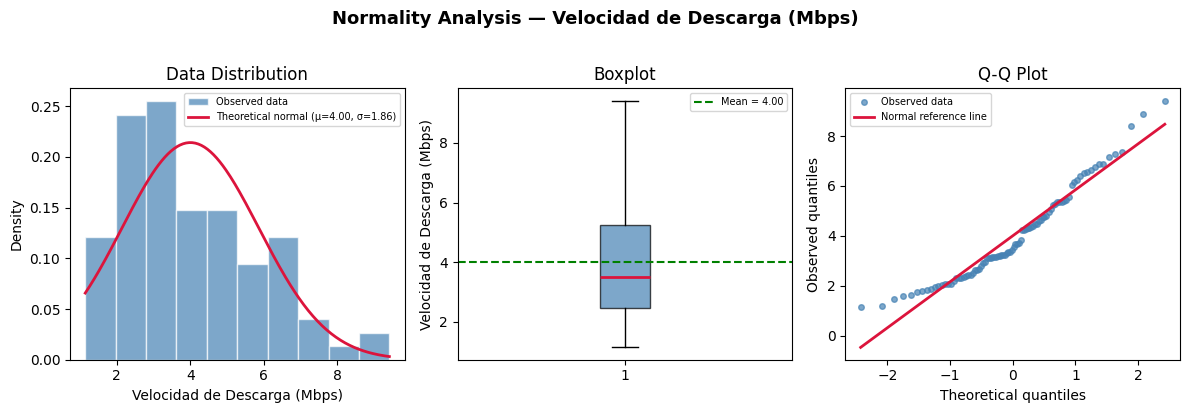

======= Shapiro Test — Velocidad de Descarga (Mbps) =======
Estadístico W:  0.9460
P-valor:        0.0010
Se rechaza H₀: los datos no siguen una distribución normal


In [118]:
PlotManager.plot_normality_analysis(download)
StatisticalManager.run_shapiro_test(download)

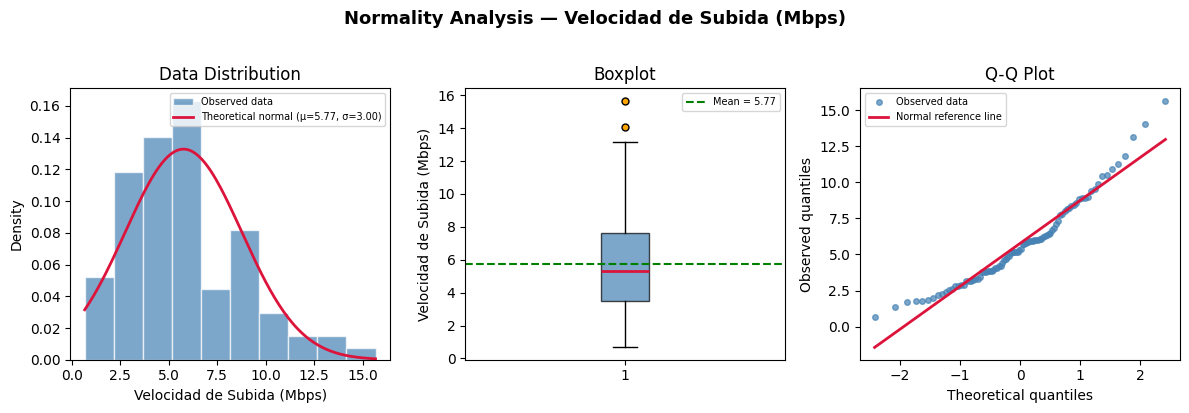

======= Shapiro Test — Velocidad de Subida (Mbps) =======
Estadístico W:  0.9491
P-valor:        0.0015
Se rechaza H₀: los datos no siguen una distribución normal


In [119]:
PlotManager.plot_normality_analysis(upload)
StatisticalManager.run_shapiro_test(upload)

In [120]:
StatisticalManager.run_wilcoxon_test(download, reference=5.0)

======= Wilcoxon Test — Velocidad de Descarga (Mbps) =======
Reference value:       5.0 Mbps
Pseudomedian:          3.86 Mbps
Theoretical 95% CI:    [3.82, 3.92] Mbps
BCa 95% CI:            [3.17, 4.32] Mbps
Statistic W:           886.0000
P-value:               0.0000

✗ H₀ rejected: evidence that true speed < 5.0 Mbps

✗ 5.0 Mbps falls outside the theoretical CI
✗ 5.0 Mbps falls outside the BCa CI


In [121]:
StatisticalManager.run_wilcoxon_test(upload, reference=2.6)

======= Wilcoxon Test — Velocidad de Subida (Mbps) =======
Reference value:       2.6 Mbps
Pseudomedian:          5.55 Mbps
Theoretical 95% CI:    [5.47, 5.61] Mbps
BCa 95% CI:            [4.60, 6.00] Mbps
Statistic W:           3920.0000
P-value:               1.0000

✓ H₀ not rejected: no evidence against 2.6 Mbps

✗ 2.6 Mbps falls outside the theoretical CI
✗ 2.6 Mbps falls outside the BCa CI


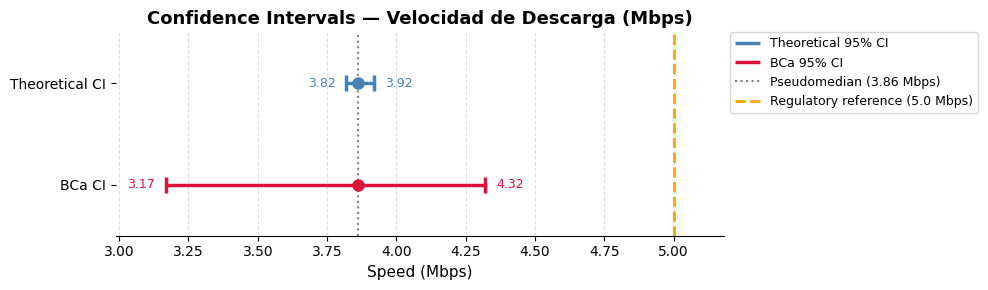

In [122]:
PlotManager.plot_confidence_intervals(
    frame=download,
    reference=5.0,
    pseudomedian=3.86,
    ci_theo=(3.82, 3.92),
    ci_bca=(3.17, 4.32),
    m = 0.1
)

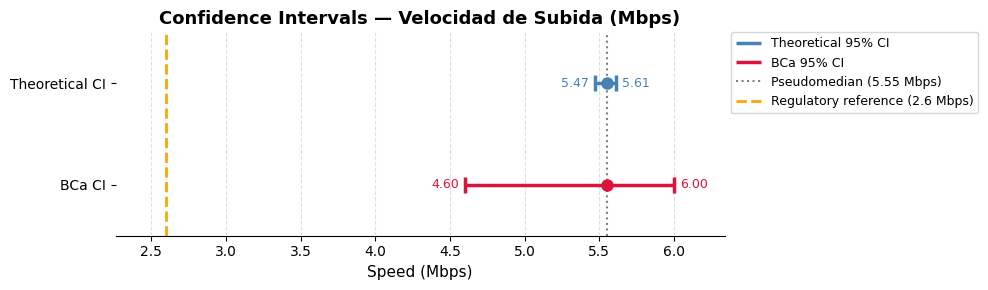

In [123]:
PlotManager.plot_confidence_intervals(
    frame=upload,
    reference=2.6,
    pseudomedian=5.55,
    ci_theo=(5.47, 5.61),
    ci_bca=(4.60, 6.00),
    m = 0.1
)